<a href="https://colab.research.google.com/github/rwcitek/FHIR-to-Parquet/blob/main/fhir-1ksample-duckdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FHIR data to DuckDB database

From https://www.kaggle.com/code/drscarlat/fhir-starter-parse-healthcare-bundles-into-tables/notebook


## Setup


In [1]:
%%capture output
%%bash
pip install -U kagglehub duckdb


In [2]:
import duckdb
import os
import json
import yaml
import kagglehub
import pprint
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
path = kagglehub.dataset_download("drscarlat/fhir-1ksample")
path


100%|██████████| 71.7M/71.7M [00:00<00:00, 88.2MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1'

## Find JSON files

In [4]:
!find {path} | sort | head -3


/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1
/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/fhir
/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/fhir/Aaron697_Brekke496_2fa15bc7-8866-461a-9000-f739e425860a.json


In [5]:
!find {path} -type f -name '*.json' | sort | head -3


/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/fhir/Aaron697_Brekke496_2fa15bc7-8866-461a-9000-f739e425860a.json
/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/fhir/Aaron697_Stiedemann542_41166989-975d-4d17-b9de-17f94cb3eec1.json
/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/fhir/Abby752_Kuvalis369_2b083021-e93f-4991-bf49-fd4f20060ef8.json


## Pick one FHIR file


In [6]:
json1 = !find {path} -type f -name '*.json' | sort
len(json1), json1[:10]


(983,
 ['/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/fhir/Aaron697_Brekke496_2fa15bc7-8866-461a-9000-f739e425860a.json',
  '/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/fhir/Aaron697_Stiedemann542_41166989-975d-4d17-b9de-17f94cb3eec1.json',
  '/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/fhir/Abby752_Kuvalis369_2b083021-e93f-4991-bf49-fd4f20060ef8.json',
  '/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/fhir/Abel832_Connelly992_29e51479-f742-4474-8f8e-d2607d5269f6.json',
  '/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/fhir/Abraham100_Heller342_262b819a-5193-404a-9787-b7f599358035.json',
  '/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/fhir/Adam631_Cronin387_aff8f143-2375-416f-901d-b0e4c73e3e58.json',
  '/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/fhir/Adam631_Shields502_9e2653fc-49e0-4b2e-86f8-e664bbe07be3.json',
  '/root/.cache/kaggle

### Explore FHIR using jq

In [7]:
!cat {json1[0]} | jq 'keys' | head


[
  "entry",
  "resourceType",
  "type"
]


In [8]:
!cat {json1[0]} | jq 'values' | head


{
  "resourceType": "Bundle",
  "type": "transaction",
  "entry": [
    {
      "fullUrl": "urn:uuid:5cbc121b-cd71-4428-b8b7-31e53eba8184",
      "resource": {
        "resourceType": "Patient",
        "id": "5cbc121b-cd71-4428-b8b7-31e53eba8184",
        "text": {


In [9]:
!cat {json1[0]} | jq 'map_values(type)'


{
  "resourceType": "string",
  "type": "string",
  "entry": "array"
}


In [10]:
!cat {json1[0]} | jq '.entry | length'


319


In [11]:
!cat {json1[0]} | jq '.entry[0] | keys' | head


[
  "fullUrl",
  "request",
  "resource"
]


In [12]:
!cat {json1[0]} | jq -r '.entry[].resource.resourceType' | sort | uniq -c | sort -rn


    187 Observation
     22 Claim
     21 ExplanationOfBenefit
     21 Encounter
     15 DiagnosticReport
     13 Procedure
     13 Immunization
     10 Condition
      5 Goal
      2 Practitioner
      2 Organization
      2 CareTeam
      2 CarePlan
      1 Patient
      1 MedicationRequest
      1 ImagingStudy
      1 Device


### Explore one FHIR file using Python

In [13]:
with open(json1[0], 'r') as f:
  fhir_data = json.load(f)


In [14]:
# top-level key values
for k ,v in fhir_data.items():
  if not isinstance(v, (list, dict)):
    print(f"{k=}, type={type(v)}, {v=}")
  else:
    print(f"{k=}, type={type(v)}")


k='resourceType', type=<class 'str'>, v='Bundle'
k='type', type=<class 'str'>, v='transaction'
k='entry', type=<class 'list'>


In [15]:
# Explore using pretty print
pprint.pprint(fhir_data, depth=4)

{'entry': [{'fullUrl': 'urn:uuid:5cbc121b-cd71-4428-b8b7-31e53eba8184',
            'request': {'method': 'POST', 'url': 'Patient'},
            'resource': {'address': [...],
                         'birthDate': '1945-12-10',
                         'communication': [...],
                         'extension': [...],
                         'gender': 'male',
                         'id': '5cbc121b-cd71-4428-b8b7-31e53eba8184',
                         'identifier': [...],
                         'maritalStatus': {...},
                         'multipleBirthBoolean': False,
                         'name': [...],
                         'resourceType': 'Patient',
                         'telecom': [...],
                         'text': {...}}},
           {'fullUrl': 'urn:uuid:8ad64ecf-c817-3753-bee7-006a8e662e06',
            'request': {'method': 'POST', 'url': 'Organization'},
            'resource': {'active': True,
                         'address': [...],
              

For the single bundle, get count of each resourceType

In [16]:
pd.Series(
  v["resource"]["resourceType"]
    for i, v in enumerate(fhir_data["entry"])
).value_counts()

,count
Observation,187
Claim,22
ExplanationOfBenefit,21
Encounter,21
DiagnosticReport,15
Immunization,13
Procedure,13
Condition,10
Goal,5
CarePlan,2


## Using DuckDB, scan each FHIR file to determine resource type of the files


In [17]:
# point to the JSON files in the kagglehub path
json_files = os.path.join(path, "**/*.json")
json_files


'/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/**/*.json'

In [18]:
# This runs the scan and returns a Pandas-like result
query = f'''
  SELECT
    resourceType,
    type,
    count(1) as count
  FROM
    read_json_auto(
      '{json_files}',
      maximum_object_size=50331648
    )
  GROUP BY ALL
'''

print(query)



  SELECT
    resourceType,
    type,
    count(1) as count
  FROM
    read_json_auto(
      '/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/**/*.json',
      maximum_object_size=50331648
    )
  GROUP BY ALL



In [19]:
duckdb.query(query).df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,resourceType,type,count
0,Bundle,transaction,983


### Drill down: count number of events per bundle

In [20]:
query = f'''
  SELECT
    reverse(string_split(reverse(filename), '/')[1]) AS bundle_id,
    resourceType,
    len(entry) AS total_entry_count
  FROM
    read_json_auto(
      '{json_files}',
      maximum_object_size=50331648,
      filename=true
    )
  ORDER BY total_entry_count DESC
'''

print(query)


  SELECT
    reverse(string_split(reverse(filename), '/')[1]) AS bundle_id,
    resourceType,
    len(entry) AS total_entry_count
  FROM
    read_json_auto(
      '/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1/**/*.json',
      maximum_object_size=50331648,
      filename=true
    )
  ORDER BY total_entry_count DESC



In [21]:
df = duckdb.query(query).df()
df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,bundle_id,resourceType,total_entry_count
0,Theodore876_Leuschke194_4eb5e041-e764-4fd6-b2a...,Bundle,17564
1,Pedro316_Rojas511_2f88c354-3ca7-487a-9718-c1fd...,Bundle,15990
2,Lorenzo669_Cuellar188_2c57a897-8381-44a6-920f-...,Bundle,4391
3,Myles862_Wunsch504_986491c5-c657-4af6-8183-08e...,Bundle,4031
4,Wilbur107_Hettinger594_57b9eb30-846e-4dd4-94b9...,Bundle,3858
...,...,...,...
978,Matilde468_Jakubowski832_cdc302e1-1148-467f-ac...,Bundle,46
979,Cassy835_Kohler843_01b6ca2a-b591-4560-9014-c37...,Bundle,36
980,Gabriella773_Cartwright189_8ccf09f3-07c3-4d93-...,Bundle,36
981,Hye44_Turner526_2c60c52c-4cb0-4b3b-b367-9343e4...,Bundle,36


#### Plot


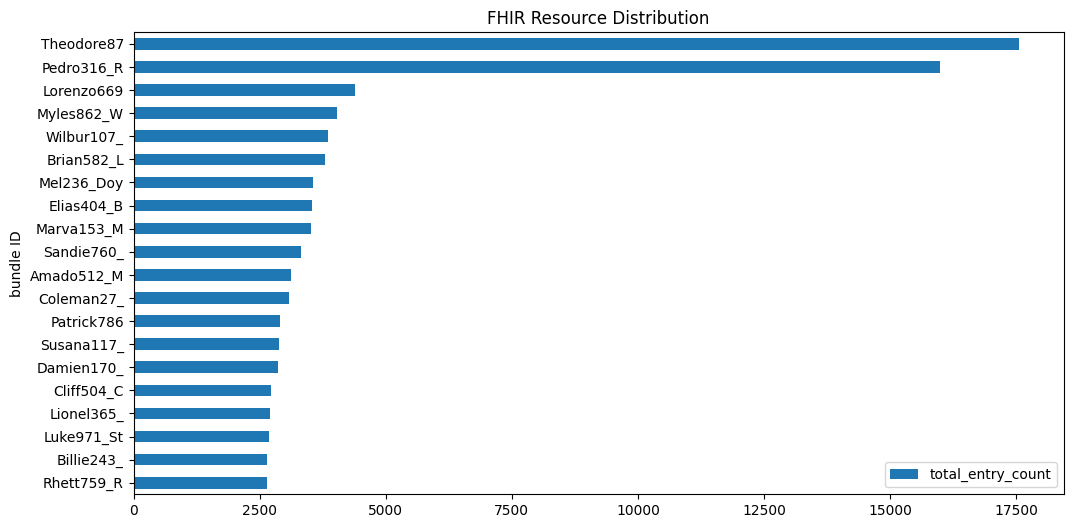

In [22]:

df["short"] = df["bundle_id"].str[:10]

ax = df.sort_values( by = ["total_entry_count"])[-20:].plot(
  figsize=(12,6),
  kind = 'barh',
  x='short',
  y='total_entry_count',
  ylabel = "bundle ID",
  title="FHIR Resource Distribution"
)

plt.show()


## Read all JSON into a parquet file

Have duckdb file for storing views


In [23]:
# Create duckdb file
con = duckdb.connect('fhir_data.db')


In [24]:
!ls -l


total 16
-rw-r--r-- 1 root root 12288 Mar 24 04:04 fhir_data.db
drwxr-xr-x 1 root root  4096 Mar 17 17:58 sample_data


### Create bundle parquet file from FHIR/JSON files with all bundles and a key

In [25]:
parquet_file = 'fhir_bundles.parquet'

con.execute(f'''
COPY (
  SELECT
    reverse(string_split(reverse(filename), '/')[1]) AS bundle_id,
    json AS bundle_data
  FROM
    read_json_objects(
      '{json_files}',
      maximum_object_size=50331648,
      filename=true
    )
) TO '{parquet_file}' (FORMAT PARQUET) ;
'''
) ;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [38]:
!ls -l --si fhi*

-rw-r--r-- 1 root root 158M Mar 24 04:04 fhir_bundles.parquet
-rw-r--r-- 1 root root  13k Mar 24 04:04 fhir_data.db


In [39]:
!du --si -s {json_files.rsplit("/",2)[0]}

1.2G	/root/.cache/kagglehub/datasets/drscarlat/fhir-1ksample/versions/1


Definitely a reduction in size.


In [44]:
con.query(f"""
  describe {parquet_file}
""").df()


,column_name,column_type,null,key,default,extra
0,bundle_id,VARCHAR,YES,None,None,None
1,bundle_data,JSON,YES,None,None,None


### Create bundle view

This simplifies queries.

In [56]:
con.execute(f'''
  CREATE OR REPLACE VIEW bundles AS
    SELECT
      string_split(string_split(bundle_id, '_')[3], '.')[1] as bundle_id,
      bundle_data
    FROM '{parquet_file}'
'''
) ;


In [57]:
!ls -l --si fhir*


-rw-r--r-- 1 root root 158M Mar 24 04:04 fhir_bundles.parquet
-rw-r--r-- 1 root root  13k Mar 24 04:04 fhir_data.db
-rw-r--r-- 1 root root  977 Mar 24 04:54 fhir_data.db.wal


In [58]:
con.query("""
  describe bundles
""").df()


,column_name,column_type,null,key,default,extra
0,bundle_id,VARCHAR,YES,None,None,None
1,bundle_data,JSON,YES,None,None,None


In [59]:
con.query("""
  SELECT
    bundle_id,
    bundle_data
  FROM bundles
  LIMIT 1
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,bundle_id,bundle_data
0,2fa15bc7-8866-461a-9000-f739e425860a,"{\n ""resourceType"": ""Bundle"",\n ""type"": ""tra..."


### Drill down one level into JSON


In [60]:
con.query("""
  SELECT
    bundle_id,
    bundle_data->>'$.resourceType' as res_type,
    bundle_data->>'$.type' as bundle_type
  FROM bundles
  LIMIT 10
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,bundle_id,res_type,bundle_type
0,2fa15bc7-8866-461a-9000-f739e425860a,Bundle,transaction
1,41166989-975d-4d17-b9de-17f94cb3eec1,Bundle,transaction
2,2b083021-e93f-4991-bf49-fd4f20060ef8,Bundle,transaction
3,29e51479-f742-4474-8f8e-d2607d5269f6,Bundle,transaction
4,262b819a-5193-404a-9787-b7f599358035,Bundle,transaction
5,aff8f143-2375-416f-901d-b0e4c73e3e58,Bundle,transaction
6,9e2653fc-49e0-4b2e-86f8-e664bbe07be3,Bundle,transaction
7,86662c9c-fcc8-41a6-a2e8-61270bf8a3b0,Bundle,transaction
8,51d71f5e-96e5-4bc0-a656-e27e10dd4f32,Bundle,transaction
9,52b1b75f-2b8a-4319-9542-7abc39502cab,Bundle,transaction


### Drill down more than one level of the JSON into the Events

In [61]:
con.query("""
  SELECT
    bundle_id,
    -- 1. Unnest the entry list
    -- 2. Access the 'resource' key
    -- 3. Extract the 'resourceType' ... for each entry in the list
    unnest((bundle_data->'$.entry')::JSON[]).resource.resourceType AS event_type
  FROM bundles
""").df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,bundle_id,event_type
0,2fa15bc7-8866-461a-9000-f739e425860a,"""Patient"""
1,2fa15bc7-8866-461a-9000-f739e425860a,"""Organization"""
2,2fa15bc7-8866-461a-9000-f739e425860a,"""Practitioner"""
3,2fa15bc7-8866-461a-9000-f739e425860a,"""Encounter"""
4,2fa15bc7-8866-461a-9000-f739e425860a,"""Condition"""
...,...,...
432822,907bd608-e768-4ce4-a5d8-4c7ba87bffa5,"""DiagnosticReport"""
432823,907bd608-e768-4ce4-a5d8-4c7ba87bffa5,"""DiagnosticReport"""
432824,907bd608-e768-4ce4-a5d8-4c7ba87bffa5,"""DiagnosticReport"""
432825,907bd608-e768-4ce4-a5d8-4c7ba87bffa5,"""Claim"""


### Explode both resource and resourceType using CTE

In [69]:
con.execute('''
CREATE OR REPLACE VIEW events AS
  WITH
    events AS (
      SELECT
        bundle_id,
        unnest((bundle_data->'$.entry')::JSON[]) as e
      FROM bundles
  ),
    resources as (
      SELECT
        bundle_id,
        e->'$.resource' as res_json
      FROM events
  )

  SELECT
    bundle_id,
    res_json->>'$.resourceType' as res_type,
    res_json
  FROM resources
''')


In [70]:
con.query('''
  select *
  from events
  limit 10
''').df()



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,bundle_id,res_type,res_json
0,2fa15bc7-8866-461a-9000-f739e425860a,Patient,"{""resourceType"":""Patient"",""id"":""5cbc121b-cd71-..."
1,2fa15bc7-8866-461a-9000-f739e425860a,Organization,"{""resourceType"":""Organization"",""id"":""8ad64ecf-..."
2,2fa15bc7-8866-461a-9000-f739e425860a,Practitioner,"{""resourceType"":""Practitioner"",""id"":""0000016d-..."
3,2fa15bc7-8866-461a-9000-f739e425860a,Encounter,"{""resourceType"":""Encounter"",""id"":""f78d73fc-9f9..."
4,2fa15bc7-8866-461a-9000-f739e425860a,Condition,"{""resourceType"":""Condition"",""id"":""4e3be31c-bb2..."
5,2fa15bc7-8866-461a-9000-f739e425860a,Condition,"{""resourceType"":""Condition"",""id"":""0472ed1c-4ef..."
6,2fa15bc7-8866-461a-9000-f739e425860a,Device,"{""resourceType"":""Device"",""id"":""64d634b4-1e7c-4..."
7,2fa15bc7-8866-461a-9000-f739e425860a,Claim,"{""resourceType"":""Claim"",""id"":""55d10840-4850-43..."
8,2fa15bc7-8866-461a-9000-f739e425860a,ExplanationOfBenefit,"{""resourceType"":""ExplanationOfBenefit"",""id"":""4..."
9,2fa15bc7-8866-461a-9000-f739e425860a,Organization,"{""resourceType"":""Organization"",""id"":""78f24216-..."


### Total counts for each resource

In [90]:
df = con.query('''
  SELECT res_type, count(1) as count
  FROM events
  GROUP BY 1
  ORDER BY count DESC
''').df()
df


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,res_type,count
0,Observation,214104
1,Claim,49340
2,Encounter,38450
3,ExplanationOfBenefit,38450
4,Procedure,30088
5,DiagnosticReport,15297
6,Immunization,12418
7,MedicationRequest,10890
8,Condition,7304
9,CareTeam,2970


#### Plot

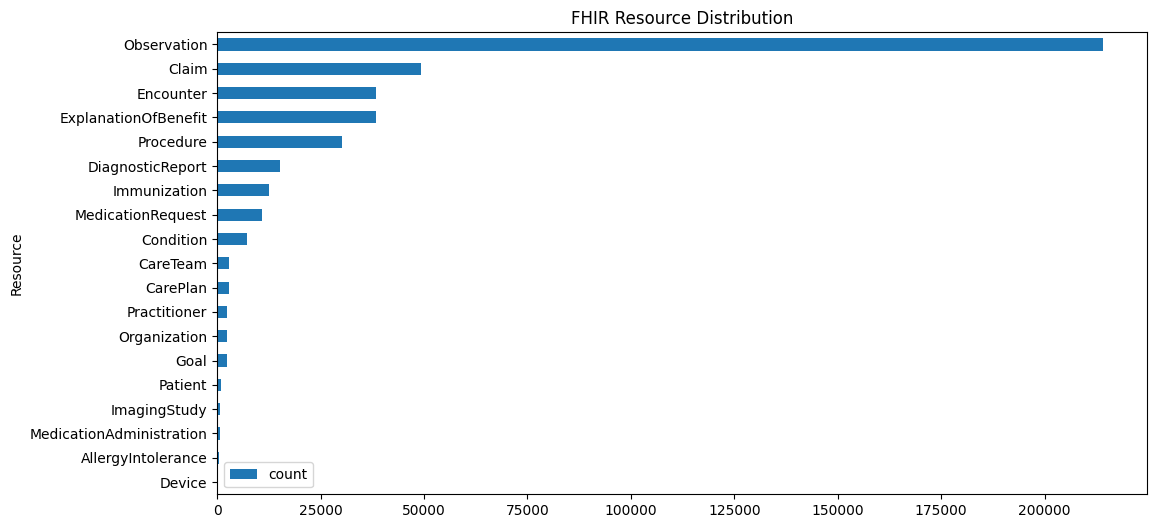

In [86]:
df.sort_values( by = ["count"] ).plot(
  figsize=(12,6),
  kind = 'barh',
  x='res_type',
  y='count',
  ylabel = "Resource",
  title="FHIR Resource Distribution",
)

plt.show()


In [87]:
!ls -l --si

total 158M
-rw-r--r-- 1 root root 158M Mar 24 04:04 fhir_bundles.parquet
-rw-r--r-- 1 root root  13k Mar 24 04:04 fhir_data.db
-rw-r--r-- 1 root root 2.2k Mar 24 05:47 fhir_data.db.wal
drwxr-xr-x 1 root root 4.1k Mar 17 17:58 sample_data


In [89]:
con.query(f'''
  select count(1)
  from events
'''
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┐
│ count(1) │
│  int64   │
├──────────┤
│   432827 │
└──────────┘

## PATIENT


### Create view

In [92]:
# PATIENT = pd.DataFrame(columns=['PatientUID', 'NameFamily', 'NameGiven', 'DoB', 'Gender'])

# print(onePatientID)
# print(onePatient.name[0].family)
# print(onePatient.name[0].given[0])
# print(onePatient.birthDate)
# print(onePatient.gender)

con.execute("""
CREATE OR REPLACE VIEW patient AS
  SELECT
    bundle_id,
    res_json->>'$.resourceType' as res_type,

    res_json->>'$.id' AS PatientUID,
    res_json->>'$.name[0].family' AS NameFamily,
    res_json->>'$.name[0].given[0]' as NameGiven,
    res_json->>'$.birthDate' AS DoB,
    res_json->>'$.gender' AS Gender,

    res_json
  FROM events
  WHERE res_type = 'Patient'
""")


### Query view

In [93]:
con.query("""
  select count(1) as count
  from patient
"""
).df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,count
0,983


In [94]:
df = con.query("""
  select *
  from patient
"""
).df()
df


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,bundle_id,res_type,PatientUID,NameFamily,NameGiven,DoB,Gender,res_json
0,2fa15bc7-8866-461a-9000-f739e425860a,Patient,5cbc121b-cd71-4428-b8b7-31e53eba8184,Brekke496,Aaron697,1945-12-10,male,"{""resourceType"":""Patient"",""id"":""5cbc121b-cd71-..."
1,41166989-975d-4d17-b9de-17f94cb3eec1,Patient,adccf2c3-9dc4-4067-ba23-98982c4875da,Stiedemann542,Aaron697,1946-03-29,male,"{""resourceType"":""Patient"",""id"":""adccf2c3-9dc4-..."
2,2b083021-e93f-4991-bf49-fd4f20060ef8,Patient,31191928-6acb-4d73-931c-e601cc3a13fa,Kuvalis369,Abby752,2002-10-24,female,"{""resourceType"":""Patient"",""id"":""31191928-6acb-..."
3,29e51479-f742-4474-8f8e-d2607d5269f6,Patient,67816396-e325-496d-a6ec-c047756b7ce4,Connelly992,Abel832,1999-12-12,male,"{""resourceType"":""Patient"",""id"":""67816396-e325-..."
4,262b819a-5193-404a-9787-b7f599358035,Patient,b426b062-8273-4b93-a907-de3176c0567d,Heller342,Abraham100,2002-04-15,male,"{""resourceType"":""Patient"",""id"":""b426b062-8273-..."
...,...,...,...,...,...,...,...,...
978,b3e09e1a-6149-4b8f-a045-29f135ad8884,Patient,b695bd67-4040-4363-b074-9926b5ff7390,Littel644,Zackary401,2017-02-04,male,"{""resourceType"":""Patient"",""id"":""b695bd67-4040-..."
979,ddd3b584-f0e6-4e6f-9700-0502ea9261c5,Patient,da81473d-6cce-4005-bf0a-c69b40fd3192,Nader710,Zackary401,1936-03-12,male,"{""resourceType"":""Patient"",""id"":""da81473d-6cce-..."
980,68ce6edb-5fe0-438c-b161-0318cd53d5d0,Patient,bd3c359e-cd66-45c9-a870-59b028c55b3a,Feest103,Zetta950,2015-08-15,female,"{""resourceType"":""Patient"",""id"":""bd3c359e-cd66-..."
981,9be7f666-14f5-48bf-919d-5e6346cb11ed,Patient,d49615b1-38b4-4c37-b59c-076636983fb7,Beatty507,Zina602,1921-07-04,female,"{""resourceType"":""Patient"",""id"":""d49615b1-38b4-..."


In [95]:
pprint.pprint(json.loads(df["res_json"][0]))

{'address': [{'city': 'Taunton',
              'country': 'US',
              'extension': [{'extension': [{'url': 'latitude',
                                            'valueDecimal': 41.93879298871088},
                                           {'url': 'longitude',
                                            'valueDecimal': -71.06682353144593}],
                             'url': 'http://hl7.org/fhir/StructureDefinition/geolocation'}],
              'line': ['894 Brakus Bypass'],
              'postalCode': '02718',
              'state': 'Massachusetts'}],
 'birthDate': '1945-12-10',
 'communication': [{'language': {'coding': [{'code': 'en-US',
                                             'display': 'English',
                                             'system': 'urn:ietf:bcp:47'}],
                                 'text': 'English'}}],
 'extension': [{'extension': [{'url': 'ombCategory',
                               'valueCoding': {'code': '2106-3',
                        

### Create parquet file

In [96]:
parquet_file = 'fhir_patient.parquet'

con.execute(f'''
COPY (
  SELECT *
  FROM patient
) TO '{parquet_file}' (FORMAT PARQUET) ;
'''
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Query parquet file

In [97]:
!ls -la {parquet_file}


-rw-r--r-- 1 root root 636809 Mar 24 06:13 fhir_patient.parquet


In [99]:
con.query(f"""
  select count(1) as count
  from '{parquet_file}'
"""
).df()


,count
0,983


## CONDITION


### Create view

In [101]:
# CONDITION = pd.DataFrame(columns=['ConditionText', 'ConditionOnsetDates', 'PatientUID'])

con.execute(f"""
CREATE OR REPLACE VIEW condition AS
  SELECT
    bundle_id,
    res_json->>'$.resourceType' as res_type,

    res_json->>'$.code.text' as ConditionText,
    res_json->>'$.onsetDateTime' as ConditionOnsetDates,
    reverse(string_split(reverse(res_json->>'$.subject.reference'), ':')[1]) AS PatientUID,

    res_json
  FROM events
  WHERE res_type = 'Condition'
""")


### Query view

In [102]:
con.query("""
  select count(1) as count
  from condition
"""
).df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,count
0,7304


In [103]:
df = con.query("""
  select *
  from condition
"""
).df()
df


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,bundle_id,res_type,ConditionText,ConditionOnsetDates,PatientUID,res_json
0,2fa15bc7-8866-461a-9000-f739e425860a,Condition,Cardiac Arrest,1965-11-15T06:22:41-05:00,5cbc121b-cd71-4428-b8b7-31e53eba8184,"{""resourceType"":""Condition"",""id"":""4e3be31c-bb2..."
1,2fa15bc7-8866-461a-9000-f739e425860a,Condition,History of cardiac arrest (situation),1965-11-15T06:22:41-05:00,5cbc121b-cd71-4428-b8b7-31e53eba8184,"{""resourceType"":""Condition"",""id"":""0472ed1c-4ef..."
2,2fa15bc7-8866-461a-9000-f739e425860a,Condition,Body mass index 30+ - obesity (finding),1977-02-21T06:22:41-05:00,5cbc121b-cd71-4428-b8b7-31e53eba8184,"{""resourceType"":""Condition"",""id"":""5dcd2d71-207..."
3,2fa15bc7-8866-461a-9000-f739e425860a,Condition,Prediabetes,1987-12-21T06:22:41-05:00,5cbc121b-cd71-4428-b8b7-31e53eba8184,"{""resourceType"":""Condition"",""id"":""e471123e-f30..."
4,2fa15bc7-8866-461a-9000-f739e425860a,Condition,Anemia (disorder),1987-12-21T06:22:41-05:00,5cbc121b-cd71-4428-b8b7-31e53eba8184,"{""resourceType"":""Condition"",""id"":""71390c66-24e..."
...,...,...,...,...,...,...
7299,907bd608-e768-4ce4-a5d8-4c7ba87bffa5,Condition,Miscarriage in first trimester,1991-09-19T10:29:43-04:00,c588a992-d308-4916-aed5-3894f7e5f6e3,"{""resourceType"":""Condition"",""id"":""5a01743e-5ae..."
7300,907bd608-e768-4ce4-a5d8-4c7ba87bffa5,Condition,Streptococcal sore throat (disorder),2009-10-26T10:29:43-04:00,c588a992-d308-4916-aed5-3894f7e5f6e3,"{""resourceType"":""Condition"",""id"":""6de08ef6-b46..."
7301,907bd608-e768-4ce4-a5d8-4c7ba87bffa5,Condition,Viral sinusitis (disorder),2014-09-14T10:29:43-04:00,c588a992-d308-4916-aed5-3894f7e5f6e3,"{""resourceType"":""Condition"",""id"":""d856a292-84a..."
7302,907bd608-e768-4ce4-a5d8-4c7ba87bffa5,Condition,Viral sinusitis (disorder),2017-02-21T09:29:43-05:00,c588a992-d308-4916-aed5-3894f7e5f6e3,"{""resourceType"":""Condition"",""id"":""10cc3f59-727..."


In [104]:
pprint.pprint(json.loads(df["res_json"][0]))

{'clinicalStatus': {'coding': [{'code': 'active',
                                'system': 'http://terminology.hl7.org/CodeSystem/condition-clinical'}]},
 'code': {'coding': [{'code': '410429000',
                      'display': 'Cardiac Arrest',
                      'system': 'http://snomed.info/sct'}],
          'text': 'Cardiac Arrest'},
 'encounter': {'reference': 'urn:uuid:f78d73fc-9f9b-46d5-93aa-f5db86ba914c'},
 'id': '4e3be31c-bb2c-479c-b855-23e3103e42d5',
 'onsetDateTime': '1965-11-15T06:22:41-05:00',
 'recordedDate': '1965-11-15T06:22:41-05:00',
 'resourceType': 'Condition',
 'subject': {'reference': 'urn:uuid:5cbc121b-cd71-4428-b8b7-31e53eba8184'},
 'verificationStatus': {'coding': [{'code': 'confirmed',
                                    'system': 'http://terminology.hl7.org/CodeSystem/condition-ver-status'}]}}


### Create parquet file

In [105]:
parquet_file = 'fhir_condition.parquet'

con.execute(f'''
COPY (
  SELECT *
  FROM condition
) TO '{parquet_file}' (FORMAT PARQUET) ;
'''
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Query parquet file

In [106]:
!ls -la {parquet_file}


-rw-r--r-- 1 root root 1251614 Mar 24 06:16 fhir_condition.parquet


In [107]:
con.query(f"""
  select count(1) as count
  from '{parquet_file}'
"""
).df()


,count
0,7304


## OBSERVATION

### Create View

In [109]:
# OBSERVATION = pd.DataFrame(columns=['ObservationText', 'ObservationValue', 'ObservationUnit', 'ObservationDate', 'PatientUID'])

con.execute("""
CREATE OR REPLACE VIEW observation AS
  SELECT
    bundle_id,
    res_json->>'$.resourceType' as res_type,

    res_json->>'$.code.text' AS ObservationText,
    res_json->>'$.valueQuantity.value' AS ObservationValue,
    res_json->>'$.valueQuantity.unit' AS ObservationUnit,
    res_json->>'$.issued' AS ObservationDate,

    reverse(string_split(reverse(res_json->>'$.subject.reference'), ':')[1]) AS PatientUID,
    res_json
  FROM events
  WHERE res_type = 'Observation'
""")



### Query view


In [110]:
con.query("""
  select count(1) as count
  from observation
"""
).df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,count
0,214104


In [111]:
df = con.query("""
  select *
  from observation
"""
).df()
df


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,bundle_id,res_type,ObservationText,ObservationValue,ObservationUnit,ObservationDate,PatientUID,res_json
0,2fa15bc7-8866-461a-9000-f739e425860a,Observation,Body Height,173.9018914060253,cm,2010-03-01T06:22:41.399-05:00,5cbc121b-cd71-4428-b8b7-31e53eba8184,"{""resourceType"":""Observation"",""id"":""9169c47c-a..."
1,2fa15bc7-8866-461a-9000-f739e425860a,Observation,Pain severity - 0-10 verbal numeric rating [Sc...,1.1844131388662626,{score},2010-03-01T06:22:41.399-05:00,5cbc121b-cd71-4428-b8b7-31e53eba8184,"{""resourceType"":""Observation"",""id"":""c5c8880a-e..."
2,2fa15bc7-8866-461a-9000-f739e425860a,Observation,Body Weight,84.16772963190675,kg,2010-03-01T06:22:41.399-05:00,5cbc121b-cd71-4428-b8b7-31e53eba8184,"{""resourceType"":""Observation"",""id"":""651a6fd5-c..."
3,2fa15bc7-8866-461a-9000-f739e425860a,Observation,Body Mass Index,27.831524855627176,kg/m2,2010-03-01T06:22:41.399-05:00,5cbc121b-cd71-4428-b8b7-31e53eba8184,"{""resourceType"":""Observation"",""id"":""6380aa12-0..."
4,2fa15bc7-8866-461a-9000-f739e425860a,Observation,Blood Pressure,None,None,2010-03-01T06:22:41.399-05:00,5cbc121b-cd71-4428-b8b7-31e53eba8184,"{""resourceType"":""Observation"",""id"":""35957c3a-8..."
...,...,...,...,...,...,...,...,...
214099,907bd608-e768-4ce4-a5d8-4c7ba87bffa5,Observation,Platelets [#/volume] in Blood by Automated count,360.5494403582584,10*3/uL,2019-07-04T10:29:43.108-04:00,c588a992-d308-4916-aed5-3894f7e5f6e3,"{""resourceType"":""Observation"",""id"":""c258a3be-4..."
214100,907bd608-e768-4ce4-a5d8-4c7ba87bffa5,Observation,Platelet distribution width [Entitic volume] i...,327.80214505467626,fL,2019-07-04T10:29:43.108-04:00,c588a992-d308-4916-aed5-3894f7e5f6e3,"{""resourceType"":""Observation"",""id"":""8fba7b72-d..."
214101,907bd608-e768-4ce4-a5d8-4c7ba87bffa5,Observation,Platelet mean volume [Entitic volume] in Blood...,10.94549449828291,fL,2019-07-04T10:29:43.108-04:00,c588a992-d308-4916-aed5-3894f7e5f6e3,"{""resourceType"":""Observation"",""id"":""1d99ff21-2..."
214102,907bd608-e768-4ce4-a5d8-4c7ba87bffa5,Observation,Tobacco smoking status NHIS,None,None,2019-07-04T10:29:43.108-04:00,c588a992-d308-4916-aed5-3894f7e5f6e3,"{""resourceType"":""Observation"",""id"":""ae58f692-e..."


In [112]:
pprint.pprint(json.loads(df["res_json"][0]))

{'category': [{'coding': [{'code': 'vital-signs',
                           'display': 'vital-signs',
                           'system': 'http://terminology.hl7.org/CodeSystem/observation-category'}]}],
 'code': {'coding': [{'code': '8302-2',
                      'display': 'Body Height',
                      'system': 'http://loinc.org'}],
          'text': 'Body Height'},
 'effectiveDateTime': '2010-03-01T06:22:41-05:00',
 'encounter': {'reference': 'urn:uuid:bae9a8f5-e741-4b46-b108-c73c2483b3a8'},
 'id': '9169c47c-a9d6-4e34-90fc-5f3b2a939984',
 'issued': '2010-03-01T06:22:41.399-05:00',
 'resourceType': 'Observation',
 'status': 'final',
 'subject': {'reference': 'urn:uuid:5cbc121b-cd71-4428-b8b7-31e53eba8184'},
 'valueQuantity': {'code': 'cm',
                   'system': 'http://unitsofmeasure.org',
                   'unit': 'cm',
                   'value': 173.9018914060253}}


### Create parquet file

In [113]:
parquet_file = 'fhir_observation.parquet'

con.execute(f'''
COPY (
  SELECT *
  FROM observation
) TO '{parquet_file}' (FORMAT PARQUET) ;
'''
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Query parquet file

In [114]:
!ls -la {parquet_file}


-rw-r--r-- 1 root root 28375454 Mar 24 06:21 fhir_observation.parquet


In [115]:
con.query(f"""
  select count(1) as count
  from '{parquet_file}'
"""
).df()


,count
0,214104


# ==== START HERE =======


In [ ]:
stop

In [ ]:


# MEDICATION = pd.DataFrame(columns=['MedicationText', 'MedicationDates', 'PatientUID'])
# PROCEDURE = pd.DataFrame(columns=['ProcedureText', 'ProcedureDates', 'PatientUID'])
# ENCOUNTER = pd.DataFrame(columns=['EncountersText', 'EncounterLocation', 'EncounterProvider','EncounterDates', 'PatientUID'])
# CLAIM = pd.DataFrame(columns=['ClaimProvider', 'ClaimInsurance', 'ClaimDate', 'ClaimType','ClaimItem','ClaimUSD', 'PatientUID'])
# IMMUNIZATION = pd.DataFrame(columns=['Immunization', 'ImmunizationDates', 'PatientUID'])



# == Demo


In [ ]:
duckdb.query('''
describe  'https://ddc-datascience.s3.amazonaws.com/big-data/fhir_bundles.parquet'
'''
)

In [ ]:
duckdb.query('''
select count(1) as count
from  'https://ddc-datascience.s3.amazonaws.com/big-data/fhir_bundles.parquet'
'''
)

In [ ]:
duckdb.query('''
select bundle_id,
    bundle_data->>'$.resourceType' as res_type,
    bundle_data->>'$.type' as bundle_type
from  'https://ddc-datascience.s3.amazonaws.com/big-data/fhir_bundles.parquet'
limit 20
  ;
'''
)

What we see is that each JSON file is a FHIR "Bundle".  A Bundle is a collection of FHIR resources that need to be handled together.  In this case

## Create DuckDB database of FHIR data

In [ ]:
# setup DuckDB
con = duckdb.connect('fhir_data.duckdb')


In [ ]:
# The 'maximum_depth' is helpful for complex FHIR structures
con.execute(f"""
    CREATE OR REPLACE TABLE fhir_raw AS
    SELECT * FROM read_json(
      '{json_files}',
      format='auto',
      maximum_depth=3,
      maximum_object_size=50331648
    );
""")


In [ ]:
df_check = con.execute("SELECT resourceType, count(*) as count FROM fhir_raw GROUP BY 1").df()
print(df_check)


In [ ]:
# PATIENT = pd.DataFrame(columns=['PatientUID', 'NameFamily', 'NameGiven', 'DoB', 'Gender'])

con.execute("""
    CREATE OR REPLACE TABLE patients AS
    SELECT
        unnest(entry).resource.id AS patient_id,
        unnest(entry).resource.gender AS gender,
        unnest(entry).resource.birthDate AS birth_date,
        unnest(entry).resource.name[1].family AS last_name
    FROM fhir_raw
    WHERE resourceType = 'Bundle';
""")


In [ ]:
con.execute("SELECT * FROM patients LIMIT 5").df()


In [ ]:
con.query("SELECT * FROM fhir_raw limit 1")


In [ ]:
raw_json = con.execute("SELECT entry->'$[0]' FROM fhir_raw LIMIT 1").fetchone()[0]


In [ ]:
len(raw_json)


In [ ]:
f"{raw_json[:100]} ... {raw_json[-100:]}"


In [ ]:
parsed_json = json.loads(raw_json)
print(json.dumps(parsed_json, indent=2))


In [ ]:
con.query("""
  with foo as (
    SELECT
        -- 1. Unnest the array into individual resource objects
        unnest(entry).resource.resourceType AS resource_type1,
        unnest(entry).resource.id AS patient_id1,
        -- unnest(entry).resource as resource1,

        unnest(entry)->>'$.resource.resourceType' AS resource_type,
        unnest(entry)->>'$.resource.id' AS resource_id,
        -- unnest(entry)->'$.resource' as resource
    FROM fhir_raw
  )
  select * from foo
  where
    -- resource_id like '225d%' and
    resource_type = 'Patient'
  limit 10
""").df().columns

In [ ]:
raw_json = con.execute('''
  with foo as (
    SELECT
        -- 1. Unnest the array into individual resource objects
        unnest(entry)->>'$.resource.resourceType' AS resource_type,
        unnest(entry)->>'$.resource.id' AS resource_id,
        unnest(entry)->>'$.resource' as resource
    FROM fhir_raw
  )
  select resource from foo
  where resource_id like '225d%' and
  resource_type = 'Patient'
  limit 1
'''
).fetchone()[0]


In [ ]:
(
  type(raw_json),
  len(raw_json),
  f"{raw_json[:30]} .. {raw_json[-30:]}"
)

In [ ]:
data_dict = json.loads(raw_json)
yaml_output = yaml.dump(data_dict, default_flow_style=False, sort_keys=True)
print(yaml_output)


In [ ]:
con.query("""
  CREATE TYPE gender_enum AS ENUM ('male', 'female');

  with foo as (
    SELECT
        -- 1. Unnest the array into individual resource objects
        unnest(entry)->>'$.resource.resourceType' AS resource_type,
        unnest(entry)->>'$.resource.id' AS resource_id,
        unnest(entry)->'$.resource' as resource
    FROM fhir_raw
  ),
  patient as (
    select
      resource_id::UUID as PatientUID,
      resource->>'$.name[0].family' as NameFamily,
      resource->>'$.name[0].given[0]' as NameGiven,
      (resource->>'$.birthDate')::DATE as DoB,
      (resource->>'$.gender')::gender_enum as Gender
    from foo
    where resource_type = 'Patient'
  )
  select *
  from patient
  limit 10
""")
